# P1 · Matrix multiplication and linear layers

Unit 0 foundations for the current Tiny Transformer and the later Phyll course. Basic Python variables, loops and functions are assumed.

Download and open this notebook in Jupyter, or choose **File → Upload notebook** in Google Colab. All examples and the required helper code are included. No account key, private repository, GPU or dataset download is needed.

Examples are **illustrative**, executed with Python and PyTorch. Newly constructed model weights are explicitly untrained. Run from a fresh kernel in order. Each exercise can run before you fill it in; open its folded solution afterward.

The `show` helper prints named intermediate results. It is course code, not a built-in Python or PyTorch function.

In [1]:
import sys, math
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
torch.set_num_threads(1)
torch.manual_seed(7)
print("Python", sys.version.split()[0], "· PyTorch", torch.__version__, "· CPU")
print("Reference environment: Python 3.12 / PyTorch 2.10. Run with Colab's installed PyTorch or the course requirements.txt.")


Python 3.12.3 · PyTorch 2.10.0+cpu · CPU
Reference environment: Python 3.12 / PyTorch 2.10. Run with Colab's installed PyTorch or the course requirements.txt.


Publication destination: the [public course labs repository](https://github.com/gkiri/tiny_repo). This notebook includes its own examples and can run before that mirror is published.

In [2]:
#@title Display helper: print and draw executed values { display-mode: "form" }
"""Small display helper embedded verbatim in independent notebooks; traces record real executions."""
import json
import math

FRAMES = []


def plain(value):
    if hasattr(value, "detach"):
        return plain(value.detach().cpu().tolist())
    if isinstance(value, dict):
        return {str(k): plain(v) for k, v in value.items()}
    if isinstance(value, (list, tuple)):
        return [plain(v) for v in value]
    if isinstance(value, float) and not math.isfinite(value):
        return str(value)
    if value is None or isinstance(value, (str, int, float, bool)):
        return value
    return str(value)


def show(label, value):
    """Print and snapshot an intermediate. This helper is course code, not a PyTorch API."""
    frame = {"label": label, "value": plain(value)}
    if hasattr(value, "shape"):
        frame.update(shape=list(value.shape), dtype=str(value.dtype), device=str(value.device))
    FRAMES.append(frame)
    print(label + ":", json.dumps(frame["value"], ensure_ascii=False))
    if "shape" in frame:
        print("  shape", frame["shape"], "·", frame["dtype"], "·", frame["device"])


def draw_trace():
    """A portable SVG trace diagram; requires only the notebook's existing IPython display."""
    import html
    from IPython.display import SVG, display
    height = 82 * len(FRAMES) + 12
    parts = [f'<svg xmlns="http://www.w3.org/2000/svg" viewBox="0 0 720 {height}" role="img" aria-label="Executed intermediate values">']
    for i, frame in enumerate(FRAMES):
        y = 8 + 82*i
        value = json.dumps(frame["value"], ensure_ascii=False)
        if len(value) > 91:
            value = value[:88] + "…"
        parts += [f'<rect x="4" y="{y}" width="708" height="68" rx="10" fill="#f4f8ef" stroke="#779861"/>',
                  f'<text x="20" y="{y+25}" font-size="15" font-family="sans-serif" fill="#31524b">{i+1}. {html.escape(frame["label"])}</text>',
                  f'<text x="20" y="{y+48}" font-size="12" font-family="monospace" fill="#252a33">{html.escape(value)}</text>']
        if i + 1 < len(FRAMES):
            parts.append(f'<path d="M360 {y+68} v14" stroke="#7042a6" stroke-width="2"/>')
    display(SVG("".join(parts) + "</svg>"))

## P1.8 · Matrix multiplication and linear layers

Matrix multiplication contracts the shared feature axis. Leading axes organize independent or broadcast products.

**Prerequisites:** Reduce along the right axis

**Predict:** What shape does [2,3] @ [3,4] produce?

**Mental model:** A linear layer combines an input vector's features into a new vector. Each output feature uses its own weighted sum of the input features.

<a id="pytorch-matmul-op"></a>

<a data-compat-cell="p1-and-broadcasting"></a>

### Why this operation exists

A linear layer combines an input vector's features into a new vector. Each output feature uses its own weighted sum of the input features.

Elementwise multiplication keeps the separate products. A dot product additionally sums them into one score.

Matrix multiplication performs many such dot products with a defined arrangement of input and output axes. The contracted inner sizes must match.

PyTorch stores a linear layer's weights as output features by input features. The calculation therefore multiplies the input by the transposed weight and adds a bias.

Attention adds leading batch and head axes. The last two axes still perform matrix multiplication while compatible leading axes organize the products.

### Follow the values

The first input vector is two, zero and one. The first output's weights are one, three and minus one.

The full weight has two outputs and three inputs. Each of its two vectors describes a different output feature.

Multiply the first input with the first weight vector entry by entry. The contributions are two, zero and minus one, summing to one.

The complete matrix product contains both output features for both input vectors. Its shape is two by two because the shared input axis has been contracted.

Add the feature biases, one half and minus one half. Doubling the input doubles the product but does not double the independently added bias.

In [3]:
FRAMES.clear()
change = 0
torch.manual_seed(7)
x = torch.tensor([[2.,0.,1.],[1.,2.,0.]]) * (2 if change else 1)
weight = torch.tensor([[1.,3.,-1.],[0.,2.,1.]])
bias = torch.tensor([.5,-.5])
show("Input [2,3]", x)
show("Weight stored [out,in]", weight)
show("Contributions to output [0,0]", x[0]*weight[0])
show("Product before bias", x @ weight.T)
show("Linear output", F.linear(x, weight, bias))
torch.testing.assert_close(F.linear(x, weight, bias), x @ weight.T + bias)

Input [2,3]: [[2.0, 0.0, 1.0], [1.0, 2.0, 0.0]]
  shape [2, 3] · torch.float32 · cpu
Weight stored [out,in]: [[1.0, 3.0, -1.0], [0.0, 2.0, 1.0]]
  shape [2, 3] · torch.float32 · cpu
Contributions to output [0,0]: [2.0, 0.0, -1.0]
  shape [3] · torch.float32 · cpu
Product before bias: [[1.0, 1.0], [7.0, 4.0]]
  shape [2, 2] · torch.float32 · cpu
Linear output: [[1.5, 0.5], [7.5, 3.5]]
  shape [2, 2] · torch.float32 · cpu


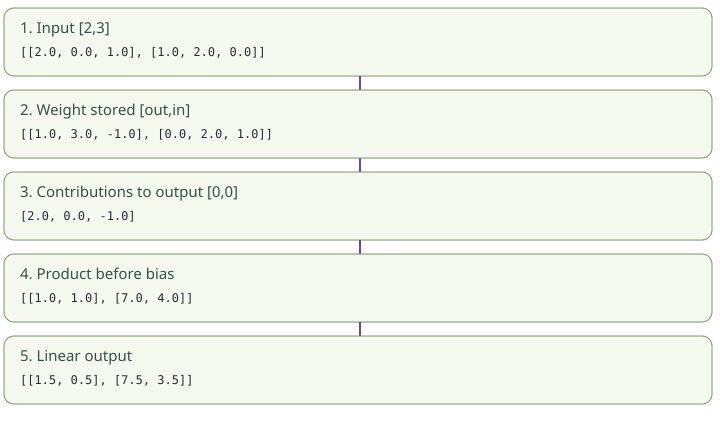

In [4]:
draw_trace()

### See the calculation

The plot uses the tensors just calculated above. Values are rounded for display.

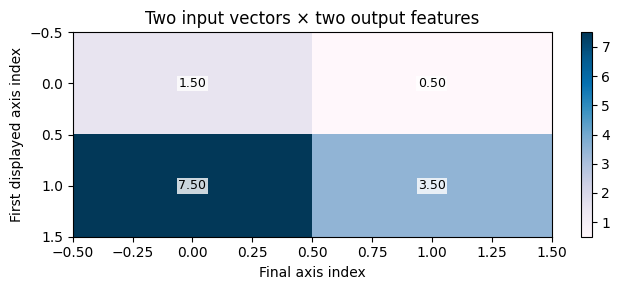

In [5]:
image = (F.linear(x,weight,bias)).detach().cpu().numpy()
fig, ax = plt.subplots(figsize=(7,3))
plot = ax.imshow(image, cmap="PuBu", aspect="auto")
for row in range(image.shape[0]):
    for col in range(image.shape[1]):
        ax.text(col,row,f"{image[row,col]:.2f}",ha="center",va="center",color="black",fontsize=9,
                bbox={"facecolor":"white","alpha":.8,"edgecolor":"none","pad":1})
ax.set_title('Two input vectors × two output features'); ax.set_xlabel("Final axis index"); ax.set_ylabel("First displayed axis index")
fig.colorbar(plot,ax=ax); plt.tight_layout(); plt.show()

### Read the implementation

The at operator performs matmul; the star operator performs elementwise multiplication. Use distinct examples to make their different output shapes visible.

Transpose this two-dimensional weight so its input axis meets the input tensor's final axis. For tensors with more axes, choose transpose axes explicitly.

Functional linear computes the same operation as a linear module using the supplied weight and bias. Compare the two calculations with assert close.

A linear module owns those parameters and registers them for an optimizer. It applies the same learned transformation to every leading batch and time position.

Batched matmul broadcasts compatible leading axes of both operands. The interactive shape explorer checks that rule before attempting the contracted product.

### Change one thing

**Double the input; keep bias fixed**. Predict which outputs change before running this second case. It executes the same code with `change = 1`.

In [6]:
FRAMES.clear()
change = 1
torch.manual_seed(7)
x = torch.tensor([[2.,0.,1.],[1.,2.,0.]]) * (2 if change else 1)
weight = torch.tensor([[1.,3.,-1.],[0.,2.,1.]])
bias = torch.tensor([.5,-.5])
show("Input [2,3]", x)
show("Weight stored [out,in]", weight)
show("Contributions to output [0,0]", x[0]*weight[0])
show("Product before bias", x @ weight.T)
show("Linear output", F.linear(x, weight, bias))
torch.testing.assert_close(F.linear(x, weight, bias), x @ weight.T + bias)

Input [2,3]: [[4.0, 0.0, 2.0], [2.0, 4.0, 0.0]]
  shape [2, 3] · torch.float32 · cpu
Weight stored [out,in]: [[1.0, 3.0, -1.0], [0.0, 2.0, 1.0]]
  shape [2, 3] · torch.float32 · cpu
Contributions to output [0,0]: [4.0, 0.0, -2.0]
  shape [3] · torch.float32 · cpu
Product before bias: [[2.0, 2.0], [14.0, 8.0]]
  shape [2, 2] · torch.float32 · cpu
Linear output: [[2.5, 1.5], [14.5, 7.5]]
  shape [2, 2] · torch.float32 · cpu


### A useful distinction

A stored nn.Linear weight is [out,in]. Multiplication by it uses the transpose; * computes a different operation.

In [7]:
q = torch.arange(2*2*3*2, dtype=torch.float32).reshape(2,2,3,2)
k = torch.ones(1,2,4,2)
scores = q @ k.transpose(-2,-1)
assert scores.shape == (2,2,3,4)
for b in range(2):
    for h in range(2):
        torch.testing.assert_close(scores[b,h], q[b,h] @ k[0,h].T)
print("Both operands can have batch axes:", tuple(scores.shape))

Both operands can have batch axes: (2, 2, 3, 4)


### ✋ Your turn

For x=[2,0,1] and weight=[1,3,-1], calculate their dot product and put its scalar in answer.

In [8]:
answer = None  # TODO: replace with your calculation

if answer is None:
    print("Your turn: fill in `answer` above, then run this cell again.")
else:
    assert answer == 1, 'A stored nn.Linear weight is [out,in]. Multiplication by it uses the transpose; * computes a different operation.'
    print("✓ right:", answer)

Your turn: fill in `answer` above, then run this cell again.


In [9]:
#@title Show a solution { display-mode: "form" }
answer = (torch.tensor([2.,0.,1.]) @ torch.tensor([1.,3.,-1.])).item()

if answer is None:
    print("Your turn: fill in `answer` above, then run this cell again.")
else:
    assert answer == 1, 'A stored nn.Linear weight is [out,in]. Multiplication by it uses the transpose; * computes a different operation.'
    print("✓ right:", answer)

✓ right: 1.0


### Reconnect to the transformer

The query-key-value projection maps each of the current model's twenty-eight features to eighty-four outputs. The three groups later become separate queries, keys and values.

Attention scores multiply queries by transposed keys. The final feature axes meet, leaving query positions and key positions as the score matrix axes.

Multiplying those scores' normalized shares by values contracts the key-position axis, returning one value mixture per query position.

The readout reuses the token embedding table as a weight. This creates a vocabulary score for each token position without a separately learned table.

Next, inspect the lookup operation that uses that same table in the input direction.

```python
att = (q @ k.transpose(-2, -1)) / math.sqrt(self.head_dim)
y = att @ v
```

The excerpt illustrates the corresponding operation. Run the complete chapter example above; excerpts can depend on model context.

**Recall:** What shape does [2,3] @ [3,4] produce?

<details><summary>Check your explanation</summary>

[2,4]. A stored nn.Linear weight is [out,in]. Multiplication by it uses the transpose; * computes a different operation.

</details>